In [6]:
from ngboost import NGBoost
from ngboost.distns import Bernoulli
from ngboost.scores import LogScore
from sklearn.tree import DecisionTreeRegressor

def build_ngboost_binary_classifier(
    n_estimators: int = 800,
    learning_rate: float = 0.05,
    max_depth: int = 3,
    min_samples_leaf: int = 20,
    random_state: int = 42,
    verbose: bool = False,
):
    """
    NGBoost binary classifier (probabilistic):
    - Learns Bernoulli(y=1 | x) as a distribution.
    - Optimizes proper scoring rule (LogScore = log loss).
    """

    # Base learner used inside boosting (like the "tree" part)
    base = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
    )

    model = NGBoost(
        Dist=Bernoulli,          # binary classification distribution
        Score=LogScore,          # log-loss / cross-entropy objective
        Base=base,               # base learner
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=random_state,
        verbose=verbose,
    )
    return model

In [5]:
import pandas as pd

df = pd.read_parquet("../data_curation/processed_data/data_with_selected_feaatures.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17633 entries, 0 to 17632
Data columns (total 83 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   SMILES                                         17633 non-null  object 
 1   MP                                             17633 non-null  float64
 2   Type                                           17633 non-null  object 
 3   RDKit_NumRotatableBonds X RDKit_fr_quatN       17633 non-null  int64  
 4   RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5          17630 non-null  float64
 5   RDKit_SlogP_VSA8 X RDKit_fr_bicyclic           17633 non-null  float64
 6   RDKit_TPSA X RDKit_NumHDonors                  17633 non-null  float64
 7   MACCS_156 X MACCS_163                          17633 non-null  int64  
 8   RDKit_SMR_VSA5 X MACCS_39                      17633 non-null  float64
 9   RDKit_Chi0v X MACCS_144                        176

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Load your selected-features parquet
df = pd.read_parquet("../data_curation/processed_data/data_with_selected_feaatures.parquet")

# Drop Type if it exists
if "Type" in df.columns:
    df = df.drop(columns=["Type"])

# Create binary target: high MP (>=250) = 1, else 0
TARGET_COL = "MP_binary_high"
df[TARGET_COL] = (df["MP"] >= 250).astype(np.int32)

print(df[[ "MP", TARGET_COL ]].head())
print("Label counts:", df[TARGET_COL].value_counts().to_dict())


      MP  MP_binary_high
0    0.0               0
1  230.0               0
2  285.0               1
3 -150.0               0
4  112.0               0
Label counts: {0: 16832, 1: 801}


Loaded: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/data_with_selected_feaatures.parquet
Shape: (17633, 83)
Using 80 RDKit feature columns.
Example: ['RDKit_NumRotatableBonds X RDKit_fr_quatN', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5', 'RDKit_SlogP_VSA8 X RDKit_fr_bicyclic', 'RDKit_TPSA X RDKit_NumHDonors', 'MACCS_156 X MACCS_163', 'RDKit_SMR_VSA5 X MACCS_39', 'RDKit_Chi0v X MACCS_144', 'RDKit_fr_NH1 X RDKit_fr_SH', 'RDKit_Kappa1 X RDKit_SlogP_VSA2', 'MACCS_126 X MACCS_127']
Rows with NaNs: 3 / 17633
After NaN removal:
  df_clean shape: (17630, 83)
  X_rdk_clean shape: (17630, 80)


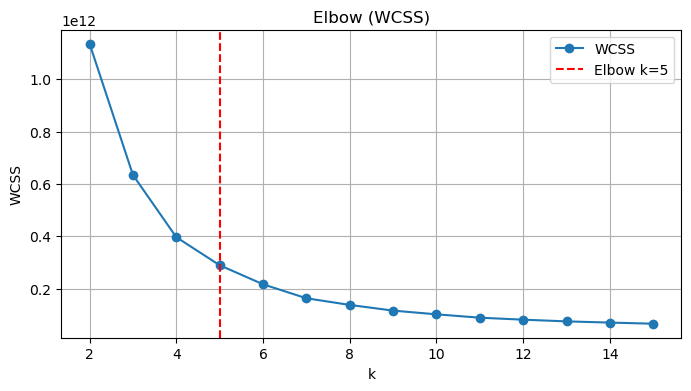

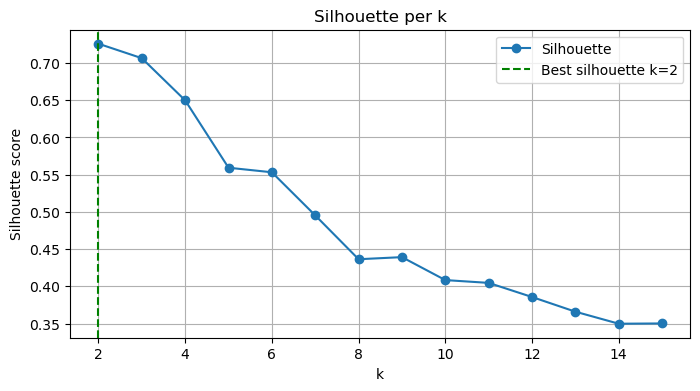

Elbow k: 5 | Best silhouette k: 2 | Selected k_opt: 5

Cluster counts:
Structure_Cluster
0    12018
1       82
2        3
3     4548
4      979
Name: count, dtype: int64

✅ Saved clustered dataset to:
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/data_selected_features_clustered_NaN.parquet

🧾 Saved removed-row log to:
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/rows_removed_due_to_nan.parquet


In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load parquet (you are in MELTING_POINT_2026/classifier/)
# ---------------------------------------------------------------------
BASE = Path.cwd()                       # .../MELTING_POINT_2026/classifier
ROOT = BASE.parent                      # .../MELTING_POINT_2026
processed_dir = ROOT / "data_curation" / "processed_data"

data_path = processed_dir / "data_with_selected_feaatures.parquet"
df = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)

# ---------------------------------------------------------------------
# 2) Drop Type + add binary label
# ---------------------------------------------------------------------
df = df.drop(columns=["Type"], errors="ignore")
df["y_binary"] = (df["MP"] >= 250).astype(int)

# ---------------------------------------------------------------------
# 3) Select RDKit numeric features only (NO scaling)
# ---------------------------------------------------------------------
exclude_cols = {"SMILES", "MP", "y_binary", "Type"}

# Exclude embedding-like / non-numeric columns
feature_cols = [
    c for c in df.columns
    if (c not in exclude_cols)
    and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Using {len(feature_cols)} RDKit feature columns.")
print("Example:", feature_cols[:10])

X_rdk = df[feature_cols].to_numpy(dtype=np.float32)

# ---------------------------------------------------------------------
# 3.5) Remove rows with NaNs in RDKit features (keep record)
# ---------------------------------------------------------------------
nan_row_mask = np.isnan(X_rdk).any(axis=1)

print(f"Rows with NaNs: {nan_row_mask.sum()} / {len(nan_row_mask)}")

# Save removed rows for record-keeping
removed_rows_df = df.loc[nan_row_mask, ["SMILES", "MP"]].copy()
removed_rows_df["reason"] = "NaN in RDKit features"

# Keep only clean rows
df_clean = df.loc[~nan_row_mask].copy()
X_rdk_clean = X_rdk[~nan_row_mask]

print("After NaN removal:")
print("  df_clean shape:", df_clean.shape)
print("  X_rdk_clean shape:", X_rdk_clean.shape)


# ---------------------------------------------------------------------
# 4) Find optimal k (same logic as your original code)
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []

    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 5) Run clustering
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(
    X_rdk_clean, max_k=15, random_state=0, plot=True
)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=0
)

df_clean["Structure_Cluster"] = kmeans.fit_predict(X_rdk_clean)

print("\nCluster counts:")
print(df_clean["Structure_Cluster"].value_counts().sort_index())



# ---------------------------------------------------------------------
# 6) Save outputs
# ---------------------------------------------------------------------
clustered_out_path = processed_dir / "data_selected_features_clustered_NaN.parquet"
removed_out_path = processed_dir / "rows_removed_due_to_nan.parquet"

df_clean.to_parquet(clustered_out_path, index=False)
removed_rows_df.to_parquet(removed_out_path, index=False)

print("\n✅ Saved clustered dataset to:")
print(clustered_out_path)

print("\n🧾 Saved removed-row log to:")
print(removed_out_path)


In [20]:
import pandas as pd

df = pd.read_parquet("../data_curation/processed_data/data_selected_features_clustered_NaN.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17630 entries, 0 to 17629
Data columns (total 84 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   SMILES                                         17630 non-null  object 
 1   MP                                             17630 non-null  float64
 2   RDKit_NumRotatableBonds X RDKit_fr_quatN       17630 non-null  int64  
 3   RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5          17630 non-null  float64
 4   RDKit_SlogP_VSA8 X RDKit_fr_bicyclic           17630 non-null  float64
 5   RDKit_TPSA X RDKit_NumHDonors                  17630 non-null  float64
 6   MACCS_156 X MACCS_163                          17630 non-null  int64  
 7   RDKit_SMR_VSA5 X MACCS_39                      17630 non-null  float64
 8   RDKit_Chi0v X MACCS_144                        17630 non-null  float64
 9   RDKit_fr_NH1 X RDKit_fr_SH                     176

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# 0) Load ALREADY-SCALED binary dataset
df_binary = pd.read_parquet("../data_curation/processed_data/data_selected_features_clustered_NaN.parquet")
TARGET_COL = "y_binary"

# Exclude non-features
exclude = {"SMILES", TARGET_COL, "MP", "Structure_Cluster"}

# Use only numeric feature columns
num_cols = df_binary.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

# Build X/y
X = df_binary[feature_cols].to_numpy(np.float32)
y = df_binary[TARGET_COL].to_numpy(np.float32)

# Stratification labels (cluster)
y_strat = df_binary["Structure_Cluster"].astype(str).to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("n features:", len(feature_cols))
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))

# 1) Fix folds once
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds = [(tr_idx, val_idx) for tr_idx, val_idx in skf.split(X, y_strat)]
print("Built folds:", len(folds))

X shape: (17630, 80)
y shape: (17630,)
n features: 80
Label counts: {np.float32(0.0): np.int64(16829), np.float32(1.0): np.int64(801)}
Built folds: 10


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


In [26]:
from sklearn.tree import DecisionTreeRegressor
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli

def evaluate_fold_ngb(
    fold_idx,
    X_train,
    y_train,
    X_val,
    y_val,
    params,
    save_checkpoints=True,
    checkpoint_dir="checkpoints_ngb_classifier",
):
    y_train = np.asarray(y_train).astype(int)
    y_val   = np.asarray(y_val).astype(int)

    # imbalance weights
    pos = y_train.sum()
    neg = y_train.size - pos
    w_pos = neg / (pos + 1e-12)
    sample_weight = np.where(y_train == 1, w_pos, 1.0)

    # ----- build base learner explicitly -----
    base = DecisionTreeRegressor(
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        min_samples_split=params["min_samples_split"],
        random_state=42,
    )

    model = NGBClassifier(
        Dist=Bernoulli,
        Base=base,                     # ✅ correct
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        minibatch_frac=params["minibatch_frac"],
        col_sample=params["col_sample"],
        random_state=42,
        verbose=False,
    )

    model.fit(X_train, y_train, sample_weight=sample_weight)

    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auc = roc_auc_score(y_val, probs)
    val_loss = log_loss(y_val, probs)
    acc = accuracy_score(y_val, preds)

    if save_checkpoints:
        ckpt_root = Path(checkpoint_dir) / f"fold_{fold_idx}"
        ckpt_root.mkdir(parents=True, exist_ok=True)

        joblib.dump(model, ckpt_root / f"ngb_model_fold_{fold_idx}.joblib")

        pd.DataFrame([{
            "fold": fold_idx,
            "val_auc": float(auc),
            "val_logloss": float(val_loss),
            "accuracy@0.5": float(acc),
            "pos_weight_used": w_pos,
        }]).to_csv(ckpt_root / f"metrics_fold_{fold_idx}.csv", index=False)

    print(
        f"[Fold {fold_idx}] AUC: {auc:.4f} | Logloss: {val_loss:.4f} | Acc@0.5: {acc:.4f} | pos_weight: {w_pos:.3f}"
    )
    return float(auc), float(val_loss), float(acc), model



In [27]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.3, 1.0),
        "col_sample": trial.suggest_float("col_sample", 0.5, 1.0),

        # base tree params (plain keys)
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
    }
    aucs, losses, accs = [], [], []

    for fold_idx, (tr_idx, val_idx) in enumerate(folds):
        X_train = X[tr_idx]
        y_train = y[tr_idx]
        X_val   = X[val_idx]
        y_val   = y[val_idx]

        trial_checkpoint_root = Path("checkpoints_ngb_classifier") / f"trial_{trial.number:03d}"

        auc, val_loss, acc, _ = evaluate_fold_ngb(
            fold_idx=fold_idx,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            params=params,
            save_checkpoints=True,
            checkpoint_dir=trial_checkpoint_root,
        )

        aucs.append(auc)
        losses.append(val_loss)
        accs.append(acc)

    avg_auc = float(np.mean(aucs))
    avg_loss = float(np.mean(losses))
    avg_acc = float(np.mean(accs))

    print(f"Trial {trial.number}: Avg AUC={avg_auc:.4f} | Avg Logloss={avg_loss:.4f} | Avg Acc@0.5={avg_acc:.4f}")

    return avg_auc


In [28]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="ngboost_binary_mp",
)

study.optimize(
    objective,
    n_trials=20,      # increase later (50–100) once it works
    show_progress_bar=True,
)

[I 2026-01-26 02:58:49,684] A new study created in memory with name: ngboost_binary_mp
  0%|          | 0/20 [00:00<?, ?it/s]

[Fold 0] AUC: 0.9206 | Logloss: 0.2955 | Acc@0.5: 0.9195 | pos_weight: 21.161
[Fold 1] AUC: 0.9354 | Logloss: 0.2568 | Acc@0.5: 0.9138 | pos_weight: 21.130
[Fold 2] AUC: 0.8809 | Logloss: 0.3396 | Acc@0.5: 0.8996 | pos_weight: 20.413
[Fold 3] AUC: 0.9226 | Logloss: 0.2801 | Acc@0.5: 0.9172 | pos_weight: 21.254
[Fold 4] AUC: 0.9230 | Logloss: 0.3002 | Acc@0.5: 0.9030 | pos_weight: 21.192
[Fold 5] AUC: 0.9300 | Logloss: 0.2784 | Acc@0.5: 0.9212 | pos_weight: 20.676
[Fold 6] AUC: 0.9225 | Logloss: 0.2851 | Acc@0.5: 0.9104 | pos_weight: 20.855
[Fold 7] AUC: 0.9020 | Logloss: 0.3680 | Acc@0.5: 0.9109 | pos_weight: 21.099
[Fold 8] AUC: 0.9365 | Logloss: 0.2731 | Acc@0.5: 0.9121 | pos_weight: 21.411


Best trial: 0. Best value: 0.919969:   5%|▌         | 1/20 [05:26<1:43:22, 326.47s/it]

[Fold 9] AUC: 0.9262 | Logloss: 0.3129 | Acc@0.5: 0.9098 | pos_weight: 20.946
Trial 0: Avg AUC=0.9200 | Avg Logloss=0.2990 | Avg Acc@0.5=0.9117
[I 2026-01-26 03:04:16,150] Trial 0 finished with value: 0.9199693611177837 and parameters: {'n_estimators': 751, 'learning_rate': 0.10705218566747088, 'minibatch_frac': 0.7972749659118191, 'col_sample': 0.6583056616604925, 'max_depth': 4, 'min_samples_leaf': 24, 'min_samples_split': 3}. Best is trial 0 with value: 0.9199693611177837.
[Fold 0] AUC: 0.9145 | Logloss: 0.2837 | Acc@0.5: 0.8826 | pos_weight: 21.161
[Fold 1] AUC: 0.9364 | Logloss: 0.2562 | Acc@0.5: 0.8860 | pos_weight: 21.130
[Fold 2] AUC: 0.8732 | Logloss: 0.3298 | Acc@0.5: 0.8746 | pos_weight: 20.413
[Fold 3] AUC: 0.9201 | Logloss: 0.2680 | Acc@0.5: 0.8911 | pos_weight: 21.254
[Fold 4] AUC: 0.9167 | Logloss: 0.2911 | Acc@0.5: 0.8786 | pos_weight: 21.192
[Fold 5] AUC: 0.9263 | Logloss: 0.2782 | Acc@0.5: 0.8832 | pos_weight: 20.676
[Fold 6] AUC: 0.9162 | Logloss: 0.2779 | Acc@0.5: 0

Best trial: 0. Best value: 0.919969:  10%|█         | 2/20 [09:31<1:23:29, 278.31s/it]

...

[Fold 9] AUC: 0.9341 | Logloss: 0.2584 | Acc@0.5: 0.9041 | pos_weight: 20.946
Trial 17: Avg AUC=0.9279 | Avg Logloss=0.2449 | Avg Acc@0.5=0.9112
[I 2026-01-26 05:35:37,621] Trial 17 finished with value: 0.9279409301899679 and parameters: {'n_estimators': 1176, 'learning_rate': 0.014880005206996226, 'minibatch_frac': 0.8942112384644868, 'col_sample': 0.5027180334885581, 'max_depth': 6, 'min_samples_leaf': 35, 'min_samples_split': 11}. Best is trial 17 with value: 0.9279409301899679.
[Fold 0] AUC: 0.9224 | Logloss: 0.2662 | Acc@0.5: 0.9138 | pos_weight: 21.161
[Fold 1] AUC: 0.9432 | Logloss: 0.2236 | Acc@0.5: 0.9178 | pos_weight: 21.130
[Fold 2] AUC: 0.8872 | Logloss: 0.2908 | Acc@0.5: 0.9013 | pos_weight: 20.413
[Fold 3] AUC: 0.9265 | Logloss: 0.2447 | Acc@0.5: 0.9155 | pos_weight: 21.254
[Fold 4] AUC: 0.9290 | Logloss: 0.2718 | Acc@0.5: 0.9064 | pos_weight: 21.192
[Fold 5] AUC: 0.9335 | Logloss: 0.2389 | Acc@0.5: 0.9155 | pos_weight: 20.676
[Fold 6] AUC: 0.9299 | Logloss: 0.2442 | Acc@

Best trial: 17. Best value: 0.927941:  95%|█████████▌| 19/20 [2:44:29<10:43, 643.54s/it]

[Fold 9] AUC: 0.9290 | Logloss: 0.2783 | Acc@0.5: 0.9053 | pos_weight: 20.946
Trial 18: Avg AUC=0.9252 | Avg Logloss=0.2602 | Avg Acc@0.5=0.9119
[I 2026-01-26 05:43:18,764] Trial 18 finished with value: 0.925206355896738 and parameters: {'n_estimators': 1107, 'learning_rate': 0.015174542856281002, 'minibatch_frac': 0.5719287526122536, 'col_sample': 0.7562151475999899, 'max_depth': 5, 'min_samples_leaf': 32, 'min_samples_split': 9}. Best is trial 17 with value: 0.9279409301899679.
[Fold 0] AUC: 0.9228 | Logloss: 0.2879 | Acc@0.5: 0.9166 | pos_weight: 21.161
[Fold 1] AUC: 0.9364 | Logloss: 0.2542 | Acc@0.5: 0.9161 | pos_weight: 21.130
[Fold 2] AUC: 0.8825 | Logloss: 0.3244 | Acc@0.5: 0.9070 | pos_weight: 20.413
[Fold 3] AUC: 0.9221 | Logloss: 0.2672 | Acc@0.5: 0.9223 | pos_weight: 21.254
[Fold 4] AUC: 0.9243 | Logloss: 0.2941 | Acc@0.5: 0.9081 | pos_weight: 21.192
[Fold 5] AUC: 0.9340 | Logloss: 0.2602 | Acc@0.5: 0.9178 | pos_weight: 20.676
[Fold 6] AUC: 0.9252 | Logloss: 0.2706 | Acc@0.

Best trial: 17. Best value: 0.927941: 100%|██████████| 20/20 [3:01:54<00:00, 545.71s/it]

[Fold 9] AUC: 0.9335 | Logloss: 0.3021 | Acc@0.5: 0.9109 | pos_weight: 20.946
Trial 19: Avg AUC=0.9224 | Avg Logloss=0.2843 | Avg Acc@0.5=0.9148
[I 2026-01-26 06:00:43,928] Trial 19 finished with value: 0.9224238850698798 and parameters: {'n_estimators': 1150, 'learning_rate': 0.025323819366959373, 'minibatch_frac': 0.8800257489693811, 'col_sample': 0.9474745636273407, 'max_depth': 6, 'min_samples_leaf': 37, 'min_samples_split': 10}. Best is trial 17 with value: 0.9279409301899679.


In [29]:
print("Best AUC:", study.best_value)
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best AUC: 0.9279409301899679
Best parameters:
  n_estimators: 1176
  learning_rate: 0.014880005206996226
  minibatch_frac: 0.8942112384644868
  col_sample: 0.5027180334885581
  max_depth: 6
  min_samples_leaf: 35
  min_samples_split: 11


In [30]:
best_params = study.best_params
print(best_params)


# Recompute class weights on full dataset
y = y.astype(int)

pos = y.sum()
neg = len(y) - pos
w_pos = neg / (pos + 1e-12)

sample_weight = np.where(y == 1, w_pos, 1.0)

# Rebuild the base learner

from sklearn.tree import DecisionTreeRegressor

base = DecisionTreeRegressor(
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    min_samples_split=best_params["min_samples_split"],
    random_state=42,
)


# Train the final model

from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
import joblib

final_model = NGBClassifier(
    Dist=Bernoulli,
    Base=base,
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    minibatch_frac=best_params["minibatch_frac"],
    col_sample=best_params["col_sample"],
    random_state=42,
    verbose=True,
)

final_model.fit(X, y, sample_weight=sample_weight)

joblib.dump(final_model, "final_ngboost_binary_model.joblib")


{'n_estimators': 1176, 'learning_rate': 0.014880005206996226, 'minibatch_frac': 0.8942112384644868, 'col_sample': 0.5027180334885581, 'max_depth': 6, 'min_samples_leaf': 35, 'min_samples_split': 11}
[iter 0] loss=1.5688 val_loss=0.0000 scale=0.5000 norm=0.9999
[iter 100] loss=0.2310 val_loss=0.0000 scale=2.0000 norm=2.7237
[iter 200] loss=0.1815 val_loss=0.0000 scale=1.0000 norm=1.4687
[iter 300] loss=0.1637 val_loss=0.0000 scale=1.0000 norm=1.5023
[iter 400] loss=0.1517 val_loss=0.0000 scale=1.0000 norm=1.5009
[iter 500] loss=0.1409 val_loss=0.0000 scale=0.5000 norm=0.7533
[iter 600] loss=0.1364 val_loss=0.0000 scale=0.5000 norm=0.7545
[iter 700] loss=0.1300 val_loss=0.0000 scale=0.0001 norm=0.0002
[iter 800] loss=0.1256 val_loss=0.0000 scale=1.0000 norm=1.5149
[iter 900] loss=0.1229 val_loss=0.0000 scale=1.0000 norm=1.4882
[iter 1000] loss=0.1157 val_loss=0.0000 scale=1.0000 norm=1.4901
[iter 1100] loss=0.1158 val_loss=0.0000 scale=1.0000 norm=1.4931


['final_ngboost_binary_model.joblib']

In [46]:
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # adjust if needed

selected_list_path = PROJECT_ROOT / "data_curation" / "processed_data" / "selected_feature_list.pkl"
with open(selected_list_path, "rb") as f:
    selected_features = pickle.load(f)

print("Loaded selected feature count:", len(selected_features))
print("First 10:", selected_features[:10])


Loaded selected feature count: 80
First 10: ['RDKit_NumRotatableBonds X RDKit_fr_quatN', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5', 'RDKit_SlogP_VSA8 X RDKit_fr_bicyclic', 'RDKit_TPSA X RDKit_NumHDonors', 'MACCS_156 X MACCS_163', 'RDKit_SMR_VSA5 X MACCS_39', 'RDKit_Chi0v X MACCS_144', 'RDKit_fr_NH1 X RDKit_fr_SH', 'RDKit_Kappa1 X RDKit_SlogP_VSA2', 'MACCS_126 X MACCS_127']


In [47]:
import pandas as pd
import numpy as np

test_file_path = (
    PROJECT_ROOT
    / "data_curation"
    / "original_curated_with_embeddings_and_MW"
    / "test_predictions"
    / "consensus_without_data_augmentation.csv"
)

test_df = pd.read_csv(test_file_path)

# Keep and rename MP column to match your featurization code (expects "MP")
test_df = test_df[["SMILES", "exp MP"]].copy()
test_df = test_df.rename(columns={"exp MP": "MP"})

# Binary label
test_df["y_binary"] = (test_df["MP"] > 250).astype(int)

print(test_df.head())
print("Label counts:", test_df["y_binary"].value_counts().to_dict())


                            SMILES     MP  y_binary
0                        BrB(Br)Br  -46.0         0
1            O=S(c1ccccc1)c1ccccc1   71.0         0
2                        CC1(C)CC1 -109.0         0
3            CCCCCCCCCCS(=O)(=O)Cl   32.0         0
4  N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C  170.0         0
Label counts: {0: 1885, 1: 76}


In [41]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MACCSkeys
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tqdm import tqdm
import xgboost as xgb
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import itertools



def smiles_to_features(dataframe, feature_type):

    data_with_features = dataframe.copy()
    
    # Extract RDKit descriptors
    if 'rdkit' in feature_type:
        # Get all RDKit descriptor names and functions (name, func)
        rdkit_descriptors = [func for name, func in Descriptors.descList]
        rdkit_names = [name for name, func in Descriptors.descList]
        
        # Extract features for each molecule
        rdkit_features = []
        for smiles in dataframe['SMILES']:
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    features = [desc(mol) for desc in rdkit_descriptors]
                else:
                    features = [np.nan] * len(rdkit_descriptors)
            except:
                features = [np.nan] * len(rdkit_descriptors)
            rdkit_features.append(features)
        
        # Add features to dataframe with prefix to avoid column name conflicts
        for i, name in enumerate(rdkit_names):
            data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
        
        print(f"✓ RDKit: Added {len(rdkit_names)} features")
    
    # Extract MACCS Keys
    if 'maccs' in feature_type:
        maccs_features = []
        for smiles in dataframe['SMILES']:
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    maccs = MACCSkeys.GenMACCSKeys(mol)
                    maccs_array = np.array(maccs)
                else:
                    maccs_array = np.array([np.nan] * 167)
            except:
                maccs_array = np.array([np.nan] * 167)
            maccs_features.append(maccs_array)
        
        # Add features to dataframe
        maccs_array = np.array(maccs_features)
        for i in range(maccs_array.shape[1]):
            data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
        
        print(f"✓ MACCS: Added 167 features")
    
    return data_with_features



def standardize_features(data, all_feature_cols, scaler_path=None, fit=True):

    df_X = data[all_feature_cols].copy()

    if fit:
        # Fit a new scaler
        scaler = StandardScaler()
        df_X_scaled = scaler.fit_transform(df_X)
        
        # Save scaler if path is provided
        if scaler_path:
            with open(scaler_path, 'wb') as f:
                pickle.dump(scaler, f)
            print(f"✓ Scaler saved to: {scaler_path}")
    else:
        # Load existing scaler
        if scaler_path is None:
            raise ValueError("scaler_path must be provided when fit=False")
        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
        print(f"✓ Scaler loaded from: {scaler_path}")
        df_X_scaled = scaler.transform(df_X)
    
    # Convert back to dataframe with original feature names and index
    df_X_scaled = pd.DataFrame(df_X_scaled, columns=df_X.columns, index=df_X.index)
    
    print(f"✓ Standardization complete. Shape: {df_X_scaled.shape}")
    
    return df_X_scaled


def reduce_features_by_variance(df_X, variance_threshold=0.01):
    
    original_features = df_X.shape[1]
    
    variances = df_X.var()
    
    selected_features = variances[variances >= variance_threshold].index.tolist()
    df_X_reduced = df_X[selected_features]
    
    remaining_features = df_X_reduced.shape[1]
    removed_features = original_features - remaining_features
    
    print(f"Original features: {original_features}")
    print(f"Removed features: {removed_features}")
    print(f"Remaining features: {remaining_features}")
    
    return df_X_reduced




def reduce_features_by_RFE(df_features, df_target, n_features_to_select, step=1, 
                          metric='rmse', cv_strategy=None):
    """
    Perform Recursive Feature Elimination (RFE) with XGBoost and cross-validation.
    """
    
    # Set default CV strategy
    if cv_strategy is None:
        cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # Flatten target if needed
    y = df_target.values.ravel() if hasattr(df_target, 'values') else df_target
    
    # Set up scoring function based on metric
    if metric.lower() == 'rmse':
        scoring = 'neg_mean_squared_error'
        def score_to_metric(scores):
            return np.sqrt(-scores)
    elif metric.lower() == 'mae':
        scoring = 'neg_mean_absolute_error'
        def score_to_metric(scores):
            return -scores
    elif metric.lower() == 'r2':
        scoring = 'r2'
        def score_to_metric(scores):
            return scores
    else:
        raise ValueError(f"Unknown metric: {metric}. Use 'rmse', 'mae', or 'r2'")
    
    # Initialize results
    results = []
    
    # Start with all features
    current_features = df_features.columns.tolist()
    iteration = 0
    
    # Create base estimator (XGBoost)
    estimator = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
    
    best_score = None
    best_features = None
    
    # Calculate number of iterations for progress bar
    n_iterations = 0
    temp_n = len(current_features)
    while temp_n > n_features_to_select:
        temp_n = max(n_features_to_select, temp_n - step)
        n_iterations += 1
        if temp_n == n_features_to_select:
            break
    
    # Iteratively eliminate features with progress bar
    pbar = tqdm(total=n_iterations, desc="RFE Feature Selection", unit="iteration", 
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} {unit}')
    
    while len(current_features) >= n_features_to_select:
        # Create RFE selector to reduce to next step
        n_features_next = max(n_features_to_select, len(current_features) - step)
        
        # Subset features
        X_current = df_features[current_features]
        
        # Perform RFE
        rfe = RFE(estimator=estimator, n_features_to_select=n_features_next, step=step)
        rfe.fit(X_current, y)
        
        # Get selected features and removed features
        selected_mask = rfe.support_
        selected_features = [current_features[i] for i in range(len(current_features)) if selected_mask[i]]
        removed_features = [current_features[i] for i in range(len(current_features)) if not selected_mask[i]]
        
        # Evaluate with cross-validation
        X_selected = X_current[selected_features]
        cv_scores = cross_val_score(estimator, X_selected, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)
        cv_scores_metric = score_to_metric(cv_scores)
        
        # Track best features
        if best_score is None or (metric.lower() == 'r2' and cv_scores_metric.mean() > best_score) or \
           (metric.lower() != 'r2' and cv_scores_metric.mean() < best_score):
            best_score = cv_scores_metric.mean()
            best_features = selected_features.copy()
        
        # Format removed features for display
        removed_str = ', '.join(removed_features)
        
        # Store results
        results.append({
            'iteration': iteration,
            'n_features': len(selected_features),
            f'{metric}_mean': cv_scores_metric.mean(),
            f'{metric}_std': cv_scores_metric.std(),
            'selected_features': selected_features.copy(),
            'removed_features': removed_features.copy()
        })
        
        # Print iteration info
        if iteration % 10 == 0:
            print(f"Iteration {iteration}/{n_iterations} | Features: {len(selected_features)} | {metric.upper()}: {cv_scores_metric.mean():.4f} ± {cv_scores_metric.std():.4f} | Removed: [{removed_str}]")
        
        # Update progress bar
        pbar.update(1)
        
        # Update for next iteration
        current_features = selected_features
        iteration += 1
        
        # Stop if we've reached the target
        if len(current_features) == n_features_to_select:
            break
    
    pbar.close()
    
    # Create summary dataframe
    summary_df = pd.DataFrame(results)
    
    # --- New Logic: Select least features within 5% of best performance ---
    metric_col = f'{metric}_mean'
    
    if metric.lower() == 'r2':
        # Higher is better
        global_best_score = summary_df[metric_col].max()
        threshold = global_best_score - abs(global_best_score) * 0.05
        # Candidates: score >= threshold
        candidates = summary_df[summary_df[metric_col] >= threshold]
    else:
        # Lower is better (RMSE, MAE)
        global_best_score = summary_df[metric_col].min()
        threshold = global_best_score + abs(global_best_score) * 0.05
        # Candidates: score <= threshold
        candidates = summary_df[summary_df[metric_col] <= threshold]
        
    # Select feature set with least features among candidates
    best_step_idx = candidates['n_features'].idxmin()
    best_step = candidates.loc[best_step_idx]
    
    best_features = best_step['selected_features']
    best_score = best_step[metric_col]
    
    print(f"\nGlobal best {metric.upper()}: {global_best_score:.4f}")
    print(f"Threshold (5% tolerance): {threshold:.4f}")
    # ----------------------------------------------------------------------

    # Reduce features to best set
    df_best_features = df_features[best_features]
    
    print(f"\n✓ RFE Feature Selection Complete (Parsimonious)")
    print(f"  Selected number of features: {len(best_features)}")
    print(f"  Selected {metric.upper()}: {best_score:.4f}")
    print(f"  Best features: {best_features[:5]}{'...' if len(best_features) > 5 else ''}")
    
    return {
        'summary': summary_df,
        'best_features': best_features,
        'n_best_features': len(best_features),
        'df_best_features': df_best_features
    }


def RFE_plot(RFE_results):
    summary = RFE_results['summary'].copy()
    
    # Sort by n_features to ensure line plot is correct
    summary = summary.sort_values(by='n_features')
    
    # Identify metric columns
    metric_col = [col for col in summary.columns if '_mean' in col][0]
    metric_std_col = metric_col.replace('_mean', '_std')
    metric_label = metric_col.split('_')[0].upper()
    
    # Identify best performance (Parsimonious: least features within 5% of global best)
    if 'r2' in metric_col.lower():
        global_best = summary[metric_col].max()
        threshold = global_best - abs(global_best) * 0.05
        candidates = summary[summary[metric_col] >= threshold]
        best_idx = candidates['n_features'].idxmin()
        direction = 'max'
    else:
        global_best = summary[metric_col].min()
        threshold = global_best + abs(global_best) * 0.05
        candidates = summary[summary[metric_col] <= threshold]
        best_idx = candidates['n_features'].idxmin()
        direction = 'min'
        
    best_n = summary.loc[best_idx, 'n_features']
    best_score = summary.loc[best_idx, metric_col]
    
    # --- Plotting Style ---
    sns.set_theme(style="ticks", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define colors
    line_color = "#2c3e50"     # Dark slate
    fill_color = "#3498db"     # Bright blue
    best_point_color = "#e74c3c" # Red
    
    # 1. Uncertainty Band (Std Dev)
    if metric_std_col in summary.columns:
        ax.fill_between(
            summary['n_features'], 
            summary[metric_col] - summary[metric_std_col],
            summary[metric_col] + summary[metric_std_col],
            color=fill_color, alpha=0.2, label='±1 Std. Dev.', zorder=1
        )
    
    # 2. Mean Score Line
    ax.plot(
        summary['n_features'], summary[metric_col], 
        color=line_color, linestyle='-', linewidth=2, 
        marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5,
        label=f'Mean {metric_label}', zorder=2
    )
    
    # 3. Highlight Best Point
    ax.scatter(
        best_n, best_score, 
        color=best_point_color, s=150, zorder=3, 
        edgecolor='white', linewidth=2, label=f'Optimal ({best_n})'
    )
    
    # 4. Vertical Dropline for Best Point (Optional, adds readability)
    ax.vlines(x=best_n, ymin=ax.get_ylim()[0], ymax=best_score, 
              colors=best_point_color, linestyles=':', alpha=0.6, zorder=0)

    # 5. Annotation
    va_align = 'bottom' if direction == 'min' else 'top'
    text_offset = (0, 15) if direction == 'min' else (0, -15)
    
    ax.annotate(
        f'{metric_label} = {best_score:.4f}',
        xy=(best_n, best_score), xytext=text_offset,
        textcoords='offset points', ha='center', va=va_align,
        fontsize=10, fontweight='bold', color=best_point_color,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=best_point_color, alpha=0.9)
    )

    # Labels & Title
    ax.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Performance ({metric_label})', fontsize=12, fontweight='bold')
    ax.set_title('RFE Performance vs. Feature Count', fontsize=14, pad=15)
    
    # Aesthetics
    sns.despine(trim=True, offset=5)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.legend(loc='best', frameon=True, framealpha=0.95, facecolor='white')
    
    plt.tight_layout()
    plt.show()

    print(f"  Optimal Feature Set: {best_n} features")
    print(f"  Best {metric_label}: {best_score:.4f}")



def feature_interaction(df):
    
    # Get all feature columns
    features = df.columns.tolist()
    
    # Generate combinations of 2 features
    # usage of combinations implies NO self-interaction (A X A)
    combinations = list(itertools.combinations(features, 2))
    
    print(f"Generating {len(combinations)} interaction features from {len(features)} original features...")
    
    # Collect new features in a dictionary
    new_features = {}
    for f1, f2 in combinations:
        feature_name = f"{f1} X {f2}"
        new_features[feature_name] = df[f1] * df[f2]
        
    # Create DataFrame from new features
    df_interactions = pd.DataFrame(new_features, index=df.index)
    
    # Concatenate with original dataframe
    df_final = pd.concat([df, df_interactions], axis=1)
    
    return df_final


def dataset_featurization(data_with_smiles, selected_features, path):

    smiles = data_with_smiles[['SMILES']]
    data_with_features = smiles_to_features(smiles, ['rdkit', 'maccs']).drop(columns=['SMILES'], axis=1)
    data_with_feature_interactions = feature_interaction(data_with_features)
    selected_features = data_with_feature_interactions[selected_features]
    final_dataset = pd.concat([data_with_smiles[['SMILES', 'MP', 'Type']], selected_features], axis=1)

    # Save final dataset
    final_dataset.to_parquet(f'{path}.parquet', index=False)
    print(f"{path} dataset saved.")

    return final_dataset

In [62]:
import numpy as np
import pandas as pd

def featurize_test_add_features_only(test_df, save_path=None):
    """
    1) Generate RDKit + MACCS + interaction features from test_df['SMILES']
    2) Do NOT select/match training features yet (keep ALL generated features)
    3) Optionally save to parquet
    """

    # Generate base features
    smiles_only = test_df[["SMILES"]].copy()
    base_feats = smiles_to_features(smiles_only, ["rdkit", "maccs"]).drop(columns=["SMILES"])

    # Add interaction features
    all_feats = feature_interaction(base_feats)

    # Final dataset (keep metadata + all generated features)
    final = pd.concat(
        [
            test_df[["SMILES", "MP", "y_binary"]].reset_index(drop=True),
            all_feats.reset_index(drop=True),
        ],
        axis=1,
    )

    if save_path is not None:
        final.to_parquet(save_path, index=False)
        print(f"Saved test dataset to: {save_path}")

    print("Final test dataset shape:", final.shape)
    return final


In [63]:
test_out_path = PROJECT_ROOT / "data_curation" / "processed_data" / "test_selected_features_trial.parquet"
test_final = featurize_test_keep_train_features(test_df, selected_features, save_path=test_out_path)

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:43: PerformanceWarning: DataFrame is highly fragmented.  Th

✓ RDKit: Added 217 features


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2916838937.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 original features...
Saved test dataset to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/test_selected_features_trial.parquet
Final test dataset shape: (1961, 83)


In [84]:
test_df = pd.read_parquet("../data_curation/processed_data/test_selected_features_trial.parquet")
test_df.head()

,SMILES,MP,y_binary,RDKit_NumRotatableBonds X RDKit_fr_quatN,RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5,RDKit_SlogP_VSA8 X RDKit_fr_bicyclic,RDKit_TPSA X RDKit_NumHDonors,MACCS_156 X MACCS_163,RDKit_SMR_VSA5 X MACCS_39,RDKit_Chi0v X MACCS_144,...,RDKit_fr_aniline X MACCS_39,RDKit_fr_Ar_COO X MACCS_43,RDKit_PEOE_VSA11 X RDKit_NumRotatableBonds,RDKit_SlogP_VSA8 X RDKit_NumRotatableBonds,RDKit_NumHeteroatoms X RDKit_RingCount,RDKit_TPSA X RDKit_fr_azide,RDKit_SMR_VSA3 X RDKit_fr_allylic_oxid,RDKit_fr_isocyan X MACCS_155,MACCS_43 X MACCS_101,RDKit_HallKierAlpha X RDKit_NumRotatableBonds
0,BrB(Br)Br,-46.0,0,0,-0.000000,0.0,0.00,0,0.0,0.0,...,0,0,0.0,0.0,0,0.0,0.0,0,0,0.00
1,O=S(c1ccccc1)c1ccccc1,71.0,0,0,-0.000000,0.0,0.00,0,0.0,0.0,...,0,0,0.0,0.0,4,0.0,0.0,0,0,-2.82
2,CC1(C)CC1,-109.0,0,0,-49.575822,0.0,0.00,0,0.0,0.0,...,0,0,0.0,0.0,0,0.0,0.0,0,0,0.00
3,CCCCCCCCCCS(=O)(=O)Cl,32.0,0,0,-116.295670,0.0,0.00,0,0.0,0.0,...,0,0,0.0,0.0,0,0.0,0.0,0,0,2.16
4,N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C,170.0,0,0,-57.934431,0.0,173.04,1,0.0,0.0,...,0,0,0.0,0.0,14,0.0,0.0,0,0,-6.44


In [75]:
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd()  # adjust if needed

model_path = PROJECT_ROOT / "final_ngboost_binary_model.joblib"
ngb = joblib.load(model_path)

print("✅ NGBoost model loaded")


✅ NGBoost model loaded


In [92]:
import numpy as np
import pandas as pd

# Your test dataframe (already featurized)
df = test_df   # rename if needed

# Columns that are NOT features
NON_FEATURE_COLS = {"SMILES", "MP", "y_binary"}

# Feature columns = everything else
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

print("Number of features:", len(feature_cols))
print("First 5 features:", feature_cols[:5])

# Build X and y
X_test = (
    df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float32)
)

X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

y_test = df["y_binary"].astype(int).to_numpy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



Number of features: 80
First 5 features: ['RDKit_NumRotatableBonds X RDKit_fr_quatN', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5', 'RDKit_SlogP_VSA8 X RDKit_fr_bicyclic', 'RDKit_TPSA X RDKit_NumHDonors', 'MACCS_156 X MACCS_163']
X_test shape: (1961, 80)
y_test shape: (1961,)


In [98]:
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd()  # adjust if needed

model_path = PROJECT_ROOT / "final_ngboost_binary_model.joblib"
ngb = joblib.load(model_path)

dist = ngb.pred_dist(X_test)
probs = np.asarray(dist.probs).reshape(-1)   # force 1D
preds = (probs >= 0.5).astype(int)

print("Preds shape:", preds.shape)

# If probs is (N,2), keep P(class=1)
if probs.ndim == 2 and probs.shape[1] == 2:
    probs = probs[:, 1]
elif probs.ndim == 1:
    probs = probs
else:
    raise ValueError(f"Unexpected probs shape: {probs.shape}")

preds = (probs >= 0.5).astype(int)

print("preds shape:", preds.shape)
print("y_test shape:", y_test.shape)

Preds shape: (3922,)
preds shape: (3922,)
y_test shape: (1961,)


In [100]:
import numpy as np
from sklearn.metrics import confusion_matrix

# --- 1) y_test must be 1D length N ---
y_test = np.asarray(y_test).astype(int).ravel()
print("y_test shape:", y_test.shape)

# --- 2) predict probs ---
dist = ngb.pred_dist(X_test)
probs = np.asarray(dist.probs)
print("raw probs shape:", probs.shape)

# --- 3) convert probs -> 1D length N ---
if probs.ndim == 2:
    # common cases: (N,2) or (2,N)
    if probs.shape[0] == y_test.shape[0] and probs.shape[1] == 2:
        probs_1d = probs[:, 1]          # take P(class=1)
    elif probs.shape[1] == y_test.shape[0] and probs.shape[0] == 2:
        probs_1d = probs[1, :]          # take P(class=1)
    else:
        raise ValueError(
            f"Cannot align probs with y_test. probs shape={probs.shape}, y_test shape={y_test.shape}"
        )
elif probs.ndim == 1:
    probs_1d = probs
else:
    raise ValueError(f"Unexpected probs ndim={probs.ndim}, shape={probs.shape}")

probs_1d = np.asarray(probs_1d).ravel()
print("probs_1d shape:", probs_1d.shape)

# --- 4) preds must be 1D length N ---
threshold = 0.5
preds = (probs_1d >= threshold).astype(int).ravel()
print("preds shape:", preds.shape)

# --- 5) final safety check ---
if preds.shape[0] != y_test.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_test={y_test.shape[0]}")

# --- 6) confusion matrix ---
cm = confusion_matrix(y_test, preds, labels=[0, 1])
print("Confusion matrix:\n", cm)


y_test shape: (1961,)
raw probs shape: (2, 1961)
probs_1d shape: (1961,)
preds shape: (1961,)
Confusion matrix:
 [[1716  169]
 [  23   53]]


In [101]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:\n", cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Confusion matrix:
 [[1716  169]
 [  23   53]]
TN=1716, FP=169, FN=23, TP=53


In [109]:
def metrics_from_confusion(cm):
    TN, FP, FN, TP = cm.ravel()

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
    }


In [110]:
metrics = metrics_from_confusion(cm)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9021
Precision: 0.2387
Recall: 0.6974
Specificity: 0.9103
F1: 0.3557


In [102]:
import numpy as np
import pandas as pd

results = test_df[["SMILES", "MP", "y_binary"]].copy()
results["prob_high"] = probs_1d  # use the 1D prob for class 1
results["pred_high"] = (results["prob_high"] >= 0.5).astype(int)

# "confidence": distance from 0.5 (0 = maximally uncertain, 0.5 = maximally confident)
results["confidence"] = np.abs(results["prob_high"] - 0.5)

# "uncertainty": the opposite (1 = most uncertain, 0 = least uncertain)
results["uncertainty"] = 1.0 - (2.0 * results["confidence"])  # ranges [0,1]

# binary correctness
results["correct"] = (results["pred_high"] == results["y_binary"]).astype(int)

results.head()


,SMILES,MP,y_binary,prob_high,pred_high,confidence,uncertainty,correct
0,BrB(Br)Br,-46.0,0,1.203765e-08,0,0.500000,2.407530e-08,1
1,O=S(c1ccccc1)c1ccccc1,71.0,0,1.098525e-08,0,0.500000,2.197050e-08,1
2,CC1(C)CC1,-109.0,0,1.280884e-08,0,0.500000,2.561769e-08,1
3,CCCCCCCCCCS(=O)(=O)Cl,32.0,0,1.704646e-08,0,0.500000,3.409292e-08,1
4,N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C,170.0,0,4.865967e-01,0,0.013403,9.731935e-01,1


In [103]:
# Bin by confidence and see accuracy in each bin
results["conf_bin"] = pd.qcut(results["confidence"], q=10, duplicates="drop")

acc_by_bin = results.groupby("conf_bin")["correct"].mean().sort_index()
count_by_bin = results.groupby("conf_bin")["correct"].size().sort_index()

print(pd.DataFrame({"n": count_by_bin, "accuracy": acc_by_bin}))


                                        n  accuracy
conf_bin                                           
(0.0013129174500000002, 0.296840428]  197  0.538071
(0.296840428, 0.464835141]            196  0.683673
(0.464835141, 0.496300581]            196  0.836735
(0.496300581, 0.499874165]            196  0.984694
(0.499874165, 0.499997584]            196  0.984694
(0.499997584, 0.499999847]            196  1.000000
(0.499999847, 0.499999964]            196  1.000000
(0.499999964, 0.499999983]            196  1.000000
(0.499999983, 0.499999988]            196  0.994898
(0.499999988, 0.49999999]             196  1.000000


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2897711116.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = results.groupby("conf_bin")["correct"].mean().sort_index()
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12800/2897711116.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_bin = results.groupby("conf_bin")["correct"].size().sort_index()


In [104]:
def selective_accuracy(df, conf_thresh):
    kept = df[df["confidence"] >= conf_thresh]
    coverage = len(kept) / len(df)
    acc = kept["correct"].mean() if len(kept) else np.nan
    return coverage, acc, len(kept)

for t in [0.05, 0.10, 0.15, 0.20, 0.25]:
    cov, acc, n = selective_accuracy(results, t)
    print(f"conf >= {t:0.2f}: coverage={cov:0.3f}, n={n}, accuracy={acc:0.3f}")


conf >= 0.05: coverage=0.984, n=1930, accuracy=0.910
conf >= 0.10: coverage=0.968, n=1899, accuracy=0.917
conf >= 0.15: coverage=0.951, n=1865, accuracy=0.921
conf >= 0.20: coverage=0.934, n=1831, accuracy=0.927
conf >= 0.25: coverage=0.920, n=1804, accuracy=0.935


In [105]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(results["y_binary"], results["prob_high"])
print("Brier score:", brier)


Brier score: 0.071025111905766


In [106]:
from sklearn.calibration import calibration_curve

y_true = results["y_binary"].to_numpy()
p = results["prob_high"].to_numpy()

frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")

calib_df = pd.DataFrame({"mean_pred_prob": mean_pred, "fraction_positive": frac_pos})
print(calib_df)


   mean_pred_prob  fraction_positive
0    1.108333e-08           0.000000
1    1.409724e-08           0.005102
2    2.421953e-08           0.000000
3    7.237952e-08           0.000000
4    8.483025e-07           0.000000
5    3.256892e-05           0.015306
6    1.229244e-03           0.005102
7    2.845208e-02           0.035714
8    2.942902e-01           0.061224
9    8.449207e-01           0.265306


In [107]:
# distance from threshold (250)
results["dist_from_250"] = np.abs(results["MP"] - 250)

# Compare uncertainty close vs far from boundary
near = results[results["dist_from_250"] <= 20]["confidence"].mean()
far  = results[results["dist_from_250"] >= 80]["confidence"].mean()

print("Mean confidence within ±20°C of 250:", near)
print("Mean confidence ≥80°C away from 250:", far)


Mean confidence within ±20°C of 250: 0.34907856459676956
Mean confidence ≥80°C away from 250: 0.4782020119606144


In [108]:
review = results[(results["confidence"] < 0.10)]
print("Need review:", len(review))

# look at most uncertain cases
review.sort_values("confidence").head(20)


Need review: 62


,SMILES,MP,y_binary,prob_high,pred_high,confidence,uncertainty,correct,conf_bin,dist_from_250
758,O=C1C(=CC(=O)c2c1cccc2)NCNc1ccccn1,135.00,0,0.501313,1,0.001313,0.997374,0,"(0.0013129174500000002, 0.296840428]",115.00
1178,BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...,215.00,0,0.503031,1,0.003031,0.993938,0,"(0.0013129174500000002, 0.296840428]",35.00
232,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2CC[C@]2([C@H...,253.85,1,0.504240,1,0.004240,0.991521,1,"(0.0013129174500000002, 0.296840428]",3.85
714,OB(c1cccc(c1Cl)Cl)O,238.00,0,0.506241,1,0.006241,0.987519,0,"(0.0013129174500000002, 0.296840428]",12.00
203,CC(=O)Nc1c(C)n(n(c1=O)c1ccccc1)C,202.00,0,0.507373,1,0.007373,0.985253,0,"(0.0013129174500000002, 0.296840428]",48.00
1660,CC1CCc2c(N1)cc1c(c2)N(C(CC1)C)C(=O)c1ccccc1,145.00,0,0.492266,0,0.007734,0.984532,1,"(0.0013129174500000002, 0.296840428]",105.00
957,Clc1cc2c(c(c1Cl)Cl)oc1c2cc(Cl)c(c1Cl)Cl,239.50,0,0.491518,0,0.008482,0.983036,1,"(0.0013129174500000002, 0.296840428]",10.50
734,BrCc1c(CBr)c(CBr)c(c(c1CBr)C)C,205.00,0,0.512527,1,0.012527,0.974947,0,"(0.0013129174500000002, 0.296840428]",45.00
4,N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C,170.00,0,0.486597,0,0.013403,0.973193,1,"(0.0013129174500000002, 0.296840428]",80.00
179,O=C(C(=O)O)Nc1ccccc1,150.00,0,0.513769,1,0.013769,0.972461,0,"(0.0013129174500000002, 0.296840428]",100.00
